# GAIA

Gaia is a space telescope launched into space by the European Space Agency.

Its primary objective is to create the most detailed 3D map of the stars in the Milky Way galaxy.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
import pandas as pd
import os

folder_path = "/kaggle/input/gaia-rvs-dataset/gaia_rvs_dataset"

# find csv files
csv_files = [
    os.path.join(folder_path, f)
    for f in os.listdir(folder_path)
    if f.lower().endswith(".csv")
]

print(f"{len(csv_files)} file is found.")

# read the files and merged it
df_list = []
for f in csv_files:
    print("Reading:", os.path.basename(f))
    df = pd.read_csv(f, sep=',', comment='#')
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

531 file is found.
Reading: RvsMeanSpectrum_676476-676499.csv
Reading: RvsMeanSpectrum_490403-490436.csv
Reading: RvsMeanSpectrum_217376-218124.csv
Reading: RvsMeanSpectrum_667498-667525.csv
Reading: RvsMeanSpectrum_639828-640055.csv
Reading: RvsMeanSpectrum_355272-355472.csv
Reading: RvsMeanSpectrum_248410-248615.csv
Reading: RvsMeanSpectrum_262134-265343.csv
Reading: RvsMeanSpectrum_209586-209771.csv
Reading: RvsMeanSpectrum_597163-597201.csv
Reading: RvsMeanSpectrum_161703-163359.csv
Reading: RvsMeanSpectrum_663216-663234.csv
Reading: RvsMeanSpectrum_059308-059485.csv
Reading: RvsMeanSpectrum_246844-246939.csv
Reading: RvsMeanSpectrum_191880-194042.csv
Reading: RvsMeanSpectrum_063328-063878.csv
Reading: RvsMeanSpectrum_669697-669740.csv
Reading: RvsMeanSpectrum_026649-027106.csv
Reading: RvsMeanSpectrum_025692-026057.csv
Reading: RvsMeanSpectrum_503325-504180.csv
Reading: RvsMeanSpectrum_055983-056374.csv
Reading: RvsMeanSpectrum_029739-030063.csv
Reading: RvsMeanSpectrum_205234-205

# Data Analysis

In [5]:
df.head()

,source_id,solution_id,ra,dec,flux,flux_error,combined_transits,combined_ccds,deblended_ccds
0,5950415474817898496,5950420259779346465,259.350995,-49.004257,"[NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0...","[NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0...",21,59,12
1,5950502198805883264,5950420259779346465,259.226565,-48.464933,"[0.9768852,1.0117651,1.0356023,1.0194464,0.971...","[0.03444636,0.036269575,0.032526437,0.03082835...",18,51,39
2,4313630715609867008,5950420259779346465,284.757556,11.756066,"[0.92617583,0.9034516,0.9119432,0.93327314,0.9...","[0.035489485,0.031482562,0.026869886,0.0221027...",10,26,15
3,4313633533114147456,5950420259779346465,284.879790,11.877190,"[0.934563,0.9105238,0.87870216,0.88756484,0.94...","[0.04333024,0.046265773,0.044620022,0.04408199...",11,28,13
4,4313635495946970880,5950420259779346465,284.741712,11.863494,"[0.91765034,0.911953,0.94897735,1.0375087,1.11...","[0.041686416,0.042669877,0.040802132,0.0427004...",9,27,14


In [6]:
print("Data shape", {df.shape})

Data shape {(208130, 9)}


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208130 entries, 0 to 208129
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   source_id          208130 non-null  int64  
 1   solution_id        208130 non-null  int64  
 2   ra                 208130 non-null  float64
 3   dec                208130 non-null  float64
 4   flux               208130 non-null  object 
 5   flux_error         208130 non-null  object 
 6   combined_transits  208130 non-null  int64  
 7   combined_ccds      208130 non-null  int64  
 8   deblended_ccds     208130 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 14.3+ MB


source_id: The star's national identification number in the universe.

flux: The star's spectrum. It is the light intensity concentrated in a narrow window between 846 nm and 870 nm.

flux_error: The uncertainty (noise) value in the flux measurement. (If the error margin is high, you can remove it from the training set)

ra,dec: Right Ascension, Declination, the sky version of the latitude and longitude system. It is a coordinate system used in astronomy to specify the position of an object in the sky.

combined_transits, combined_ccds: How many times Gaia observed this star. The more observations, the higher the quality of the spectrum.

In [8]:
df.describe()

,source_id,solution_id,ra,dec,combined_transits,combined_ccds,deblended_ccds
count,2.081300e+05,2.081300e+05,208130.000000,208130.000000,208130.000000,208130.000000,208130.000000
mean,1.886144e+18,5.950420e+18,173.891742,24.700391,23.923159,66.168885,11.755821
std,1.796289e+18,3.618825e+06,103.970827,34.744941,10.170910,28.428134,9.749548
min,3.332895e+12,5.950420e+18,0.000205,-75.624592,3.000000,6.000000,0.000000
25%,6.018385e+17,5.950420e+18,85.860954,13.691493,17.000000,47.000000,5.000000
50%,1.398841e+18,5.950420e+18,158.833404,32.604794,23.000000,62.000000,9.000000
75%,2.000245e+18,5.950420e+18,257.097434,49.478302,29.000000,81.000000,16.000000
max,6.914576e+18,5.950420e+18,359.999807,89.581055,197.000000,562.000000,160.000000


In [9]:
df.isnull().sum() # There are no missing values in the dataset

source_id            0
solution_id          0
ra                   0
dec                  0
flux                 0
flux_error           0
combined_transits    0
combined_ccds        0
deblended_ccds       0
dtype: int64

# Sky Distribution of Gaia Resources

In [10]:
df[["ra","dec"]].describe()

,ra,dec
count,208130.000000,208130.000000
mean,173.891742,24.700391
std,103.970827,34.744941
min,0.000205,-75.624592
25%,85.860954,13.691493
50%,158.833404,32.604794
75%,257.097434,49.478302
max,359.999807,89.581055


In [11]:
# ra (Right Ascension) => Horizontal position in the sky (longitude) (0,360)
# dec (Declination) => Vertical position in the sky (latitude) (-90,+90)

# Assigning an (x,y) coordinate to each star.

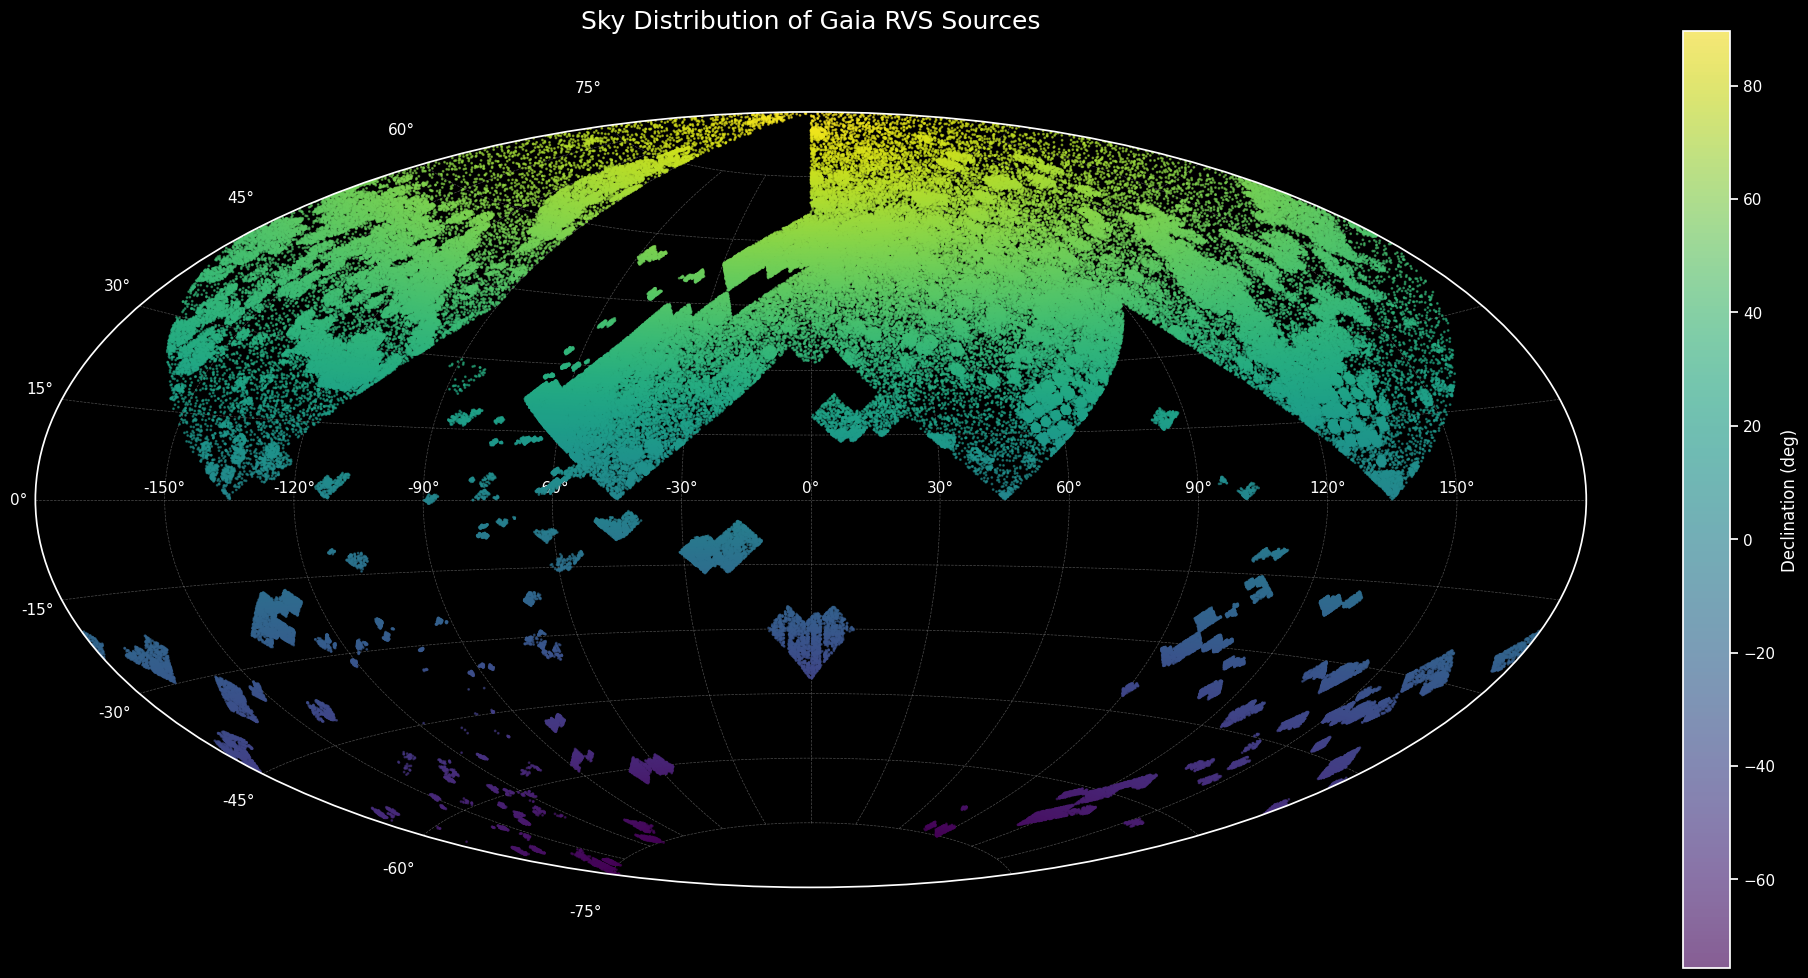

In [12]:
sns.set_theme(style="dark")

plt.rcParams["axes.edgecolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
plt.rcParams["text.color"] = "white"

ra = df["ra"].values
dec = df["dec"].values

# Convert RA values to radians and wrap them around the range -180 to +180 (because we are using aitoff as a projection)
ra_rad = np.deg2rad(ra)
ra_rad[ra_rad > np.pi] -= 2*np.pi  # Squeeze the ra data into the range -180,+180

dec_rad = np.deg2rad(dec)

plt.figure(figsize=(20,10))
ax = plt.subplot(111, projection="aitoff") # It is a projection that projects a spherical surface onto a 2D plane in an oval (elliptical) shape.

sc = plt.scatter(
    ra_rad,
    dec_rad,
    s=1,                # The size of the points
    alpha=0.6,
    c=dec,              
    cmap="viridis"     
)

# Background
ax.set_facecolor("black")              # It sets the aitoff project
plt.gcf().patch.set_facecolor("black") # It sets the whole background except aitoff projection

plt.title("Sky Distribution of Gaia RVS Sources", pad=60, fontsize=18)
plt.grid(True, color="white", linestyle="--", linewidth=0.5, alpha=0.3)

# Colarbar
cbar = plt.colorbar(sc, pad=0.05) 
cbar.set_label("Declination (deg)", color="white")

plt.tight_layout()
plt.show()

# Flux and Flux Error Analysis

In [13]:
df["flux"][1000]  # flux values are stored as an JSON format.

'[0.96651965,0.96668637,0.9612263,0.9678575,0.9767394,0.988906,0.9960742,0.9985788,0.9999502,0.9982344,1.0004166,0.99734354,0.9947416,0.9950487,0.9954401,0.99308676,0.9875557,0.9854404,0.9912824,0.9952398,0.99128634,0.98505455,0.98388106,0.9886988,0.9913831,0.9900074,0.9842457,0.9810949,0.9876041,1.0001471,1.0132805,1.0238087,1.0284991,1.0242605,1.0197388,1.0231432,1.0295169,1.0297983,1.0222722,1.013669,1.0080694,1.0134714,1.0297123,1.0373553,1.0348378,1.0286412,1.0240887,1.0251125,1.0290732,1.0293064,1.0251662,1.0238503,1.0198545,1.0125035,0.9965868,0.9798686,0.9647754,0.9622119,0.97122777,0.98015606,0.9792723,0.9741938,0.98083985,0.9917421,1.00431,1.0165129,1.0210215,1.0200849,1.0201212,1.0212249,1.010163,0.98741937,0.9679166,0.9562999,0.95220715,0.9459663,0.940536,0.93073136,0.9239863,0.9218941,0.92704445,0.92822295,0.93204784,0.9398559,0.95432293,0.9624644,0.96008605,0.96086365,0.9636979,0.9687517,0.970169,0.9711563,0.9762565,0.97282356,0.9637411,0.95852786,0.9645965,0.9789672,0.98

In [14]:
def convert_array(flux_string):

    return np.fromstring(flux_string.strip("[]"), sep=",", dtype=np.float32)  # np.fromstring() reads numbers from a string and converts them to a NumPy array

df["flux_norm"] = df["flux"].apply(convert_array)
df["flux_error_norm"] = df["flux_error"].apply(convert_array)

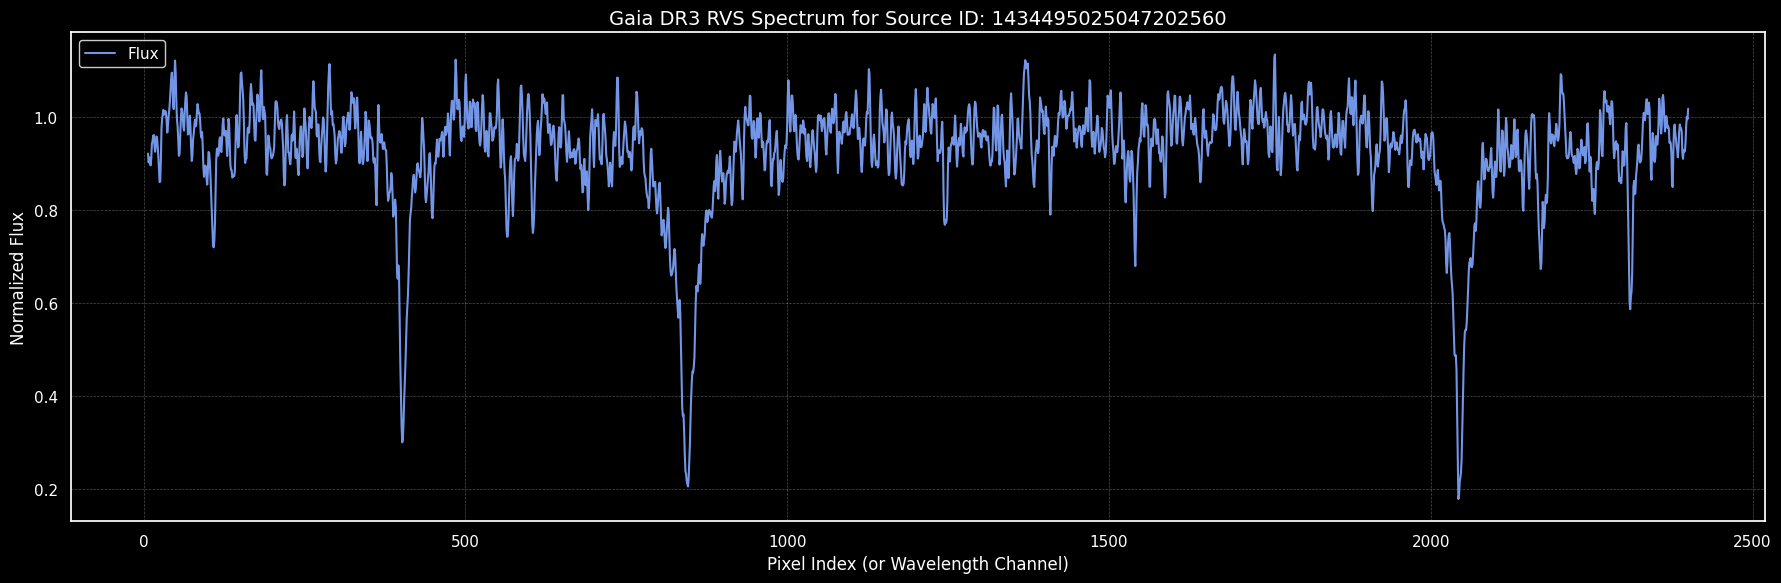

In [15]:
source_id = df['source_id'].iloc[5000]
flux = df['flux_norm'].iloc[5000]

# Graph
plt.figure(figsize=(18,6))
ax = plt.gca()

plt.plot(
    flux,
    color="#7FA6FF",   
    linewidth=1.5,
    alpha=0.9,
    label="Flux"
)

# Background
ax.set_facecolor("black")
plt.gcf().patch.set_facecolor("black")

plt.title(
    f"Gaia DR3 RVS Spectrum for Source ID: {source_id}",
    fontsize=14,
    color="white"
)

plt.xlabel("Pixel Index (or Wavelength Channel)", fontsize=12, color="white")
plt.ylabel("Normalized Flux", fontsize=12, color="white")

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
plt.legend(facecolor="black", edgecolor="white", loc="upper left")

plt.tight_layout()

In [16]:
print(pd.isnull(None))
print(pd.isnull(5))

True
False


In [ ]:
df["flux_norm"].apply(lambda x: sum(pd.isnull(x))) # Flux data has some missing valus

In [17]:
def fill_nan_with_row_mean(arr):

    row_mean = np.nanmean(arr)   # Calculate the row average without taking nan
    nan_mask = np.isnan(arr)     # Identify the nan values
    arr[nan_mask] = row_mean     # Fill the nan valus with row mean

    return arr

In [18]:
df["flux_norm"] = df["flux_norm"].apply(lambda x: fill_nan_with_row_mean(x))
df["flux_error_norm"] = df["flux_error_norm"].apply(lambda x: fill_nan_with_row_mean(x))

In [19]:
print(f"Total number of samples in the dataset: {len(df)}")
print(f"Each flux profile consists of {len(df['flux_norm'][0])} data points")

Total number of samples in the dataset: 208130
Each flux profile consists of 2401 data points


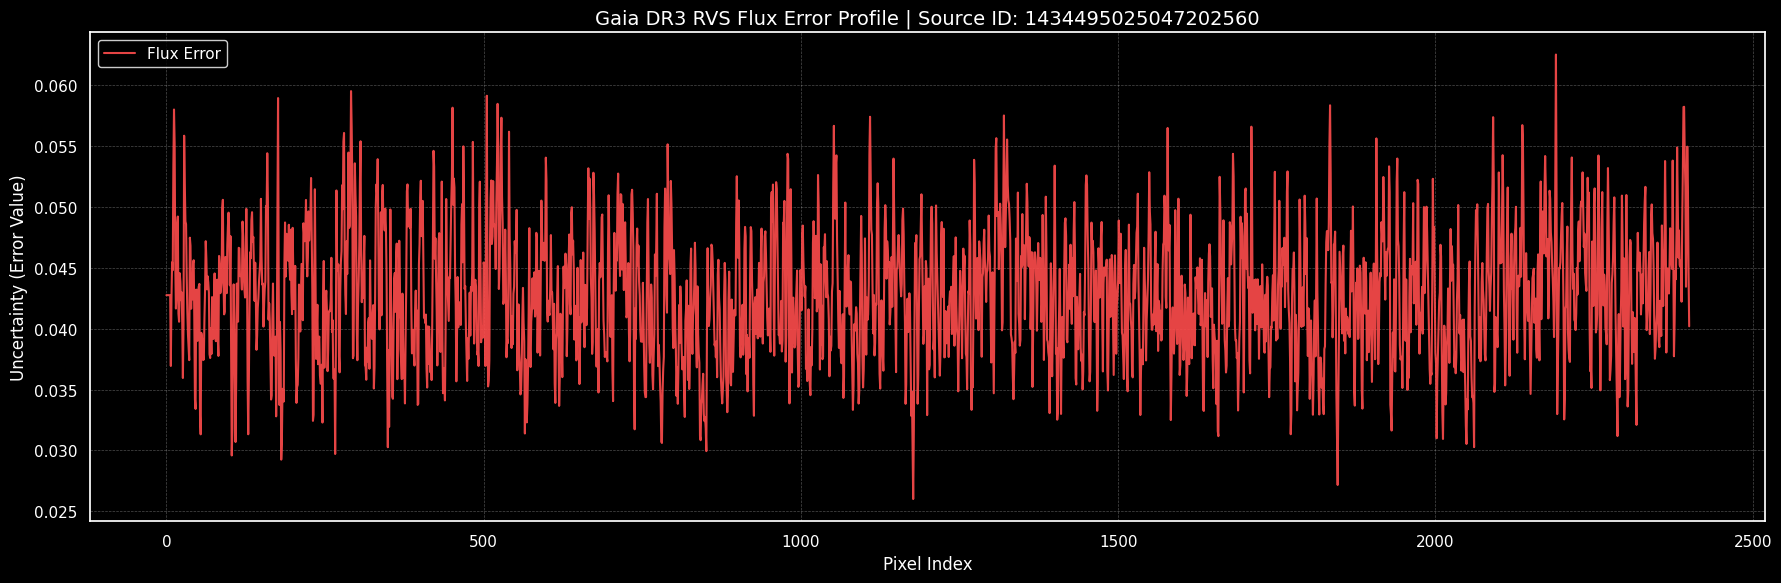

In [20]:
source_id = df['source_id'].iloc[5000]
flux_error = df['flux_error_norm'].iloc[5000]

plt.figure(figsize=(18,6))
ax = plt.gca()

plt.plot(
    flux_error,
    color="#FF4C4C",   
    linewidth=1.5,
    alpha=0.9,
    label="Flux Error"
)

ax.set_facecolor("black")
plt.gcf().patch.set_facecolor("black")

plt.title(
    f"Gaia DR3 RVS Flux Error Profile | Source ID: {source_id}",
    fontsize=14,
    color="white"
)

plt.xlabel("Pixel Index", fontsize=12, color="white")
plt.ylabel("Uncertainty (Error Value)", fontsize=12, color="white")

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
plt.legend(facecolor="black", edgecolor="white", loc="upper left")

plt.tight_layout()

In [21]:
df.drop("flux", axis=1, inplace=True)        # Delete the original columns after the normalization
df.drop("flux_error", axis=1, inplace=True)

# Target Value Analysis

In [23]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 74.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.0 MB/s eta 0:00:00


In [24]:
from astroquery.gaia import Gaia   # astroquery.gaia is a specialized software library that allows people to access the Gaia Space Telescope's massive data archive with Python
import time

# 1. Prepare unique ID list
unique_ids = df['source_id'].unique().tolist()
print(f"Total of {len(unique_ids)} IDs to be queried.")

# 2. Settings
batch_size = 500 # Safest limit for the IN clause
teff_results_list = []
total_count = len(unique_ids)
print("Starting query (Direct fetching without manual upload)...")

# 3. Loop
for i in range(0, total_count, batch_size):
    batch = unique_ids[i:i + batch_size]
    # Convert ID list to string (for SQL Format)
    ids_str = ",".join(map(str, batch))

    # Go to the gaia_source table in Gaia DR3 archive, take the only the ID number and Teff value of stars with this ID500.
    query = f"""                             
    SELECT source_id, teff_gspphot
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    
    try:
        # Launching asynchronous job directly
        job = Gaia.launch_job_async(query)    # Python sends a request over the internet to GAİA'S API endpoint with using Gaia.launch_job_async(query) (Launch and Track)
        batch_df = job.get_results().to_pandas()
        teff_results_list.append(batch_df)
        
        if (i // batch_size) % 10 == 0: # Status update every 10 batches
             print(f"Progress: {i}/{total_count} stars completed...")
             
    except Exception as e:
        print(f"!!! Error in range {i} - {i+batch_size}: {e}")
        # Wait a bit on error as recommended by Gaia
        time.sleep(5)
    
    # Short sleep to avoid overwhelming the server
    time.sleep(0.5)

# 4. Merge results (if the list is not empty)
if teff_results_list:
    final_teff_df = pd.concat(teff_results_list, ignore_index=True)
    final_teff_df = final_teff_df.dropna(subset=['teff_gspphot'])
    final_teff_df.to_csv("gaia_teff_target_531.csv", index=False)
    print(f"\nProcess Completed! {len(final_teff_df)} valid records retrieved.")
else:
    print("\nUnfortunately, no data could be retrieved. The Gaia Archive might be down.")

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
Total of 208130 IDs to be queried.
Starting query (Direct fetching without manual upload)...
INFO: Query finished. [astroquery.utils.tap.core]
Progress: 0/208130 stars completed...
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query

In [25]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

df = df.merge(final_teff_df, on="source_id", how="left")  # Merge the target value into the df with using source_id
df.head()

,source_id,solution_id,ra,dec,combined_transits,combined_ccds,deblended_ccds,flux_norm,flux_error_norm,teff_gspphot
0,5950415474817898496,5950420259779346465,259.350995,-49.004257,21,59,12,"[0.9151915, 0.9151915, 0.9151915, 0.9151915, 0...","[0.045158558, 0.045158558, 0.045158558, 0.0451...",4722.206543
1,5950502198805883264,5950420259779346465,259.226565,-48.464933,18,51,39,"[0.9768852, 1.0117651, 1.0356023, 1.0194464, 0...","[0.03444636, 0.036269575, 0.032526437, 0.03082...",NaN
2,4313630715609867008,5950420259779346465,284.757556,11.756066,10,26,15,"[0.92617583, 0.9034516, 0.9119432, 0.93327314,...","[0.035489485, 0.031482562, 0.026869886, 0.0221...",NaN
3,4313633533114147456,5950420259779346465,284.879790,11.877190,11,28,13,"[0.934563, 0.9105238, 0.87870216, 0.88756484, ...","[0.04333024, 0.046265773, 0.044620022, 0.04408...",10175.013672
4,4313635495946970880,5950420259779346465,284.741712,11.863494,9,27,14,"[0.91765034, 0.911953, 0.94897735, 1.0375087, ...","[0.041686416, 0.042669877, 0.040802132, 0.0427...",4652.980957


In [26]:
teff_clean = df.dropna(subset=["teff_gspphot"])  # If teff_gspphot is missing drop the column
teff_clean.shape

(136025, 10)

In [27]:
bins = [0, 3700, 5200, 6000, 7500, 10000, 30000, 100000]
labels = ['M', 'K', 'G', 'F', 'A', 'B', 'O']

# Create the target class
teff_clean['spectral_class'] = pd.cut(teff_clean['teff_gspphot'], bins=bins, labels=labels)

print(teff_clean['spectral_class'].value_counts())

spectral_class
K    50666
G    50308
F    22759
B     6499
M     3865
A     1915
O       13
Name: count, dtype: int64


/tmp/ipykernel_94/2470603780.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teff_clean['spectral_class'] = pd.cut(teff_clean['teff_gspphot'], bins=bins, labels=labels)


In [28]:
teff_clean[teff_clean["spectral_class"] == "O"]  # The informations of stars with spectral class "O"

,source_id,solution_id,ra,dec,combined_transits,combined_ccds,deblended_ccds,flux_norm,flux_error_norm,teff_gspphot,spectral_class
7285,227678247885181184,5950420259779346465,65.431469,40.278149,26,73,4,"[0.92541224, 0.9372935, 0.95077586, 0.96505725...","[0.0086550405, 0.0081017595, 0.008387187, 0.00...",34788.808594,O
23338,61445318262261504,5950420259779346465,51.769117,21.340880,13,38,2,"[0.93819326, 0.93819326, 1.0218383, 0.9729502,...","[0.010292895, 0.010292895, 0.08875661, 0.04179...",34999.179688,O
40708,524848546929032320,5950420259779346465,20.918615,64.786146,24,68,10,"[0.9248841, 0.9248841, 0.9248841, 0.9248841, 0...","[0.032776978, 0.032776978, 0.032776978, 0.0327...",31542.986328,O
47570,2002125947376235136,5950420259779346465,341.677341,53.401270,24,68,30,"[0.93092775, 0.93092775, 0.93092775, 0.9309277...","[0.01862989, 0.01862989, 0.01862989, 0.0186298...",34993.722656,O
50945,131281383414696704,5950420259779346465,37.997651,29.623466,8,22,6,"[0.9518576, 0.95804, 0.9631863, 0.98396, 0.991...","[0.020926777, 0.023151778, 0.023137486, 0.0214...",34999.871094,O
65808,486755103287631360,5950420259779346465,52.776803,61.939738,20,52,6,"[0.9331273, 0.9331273, 0.9331273, 0.9331273, 0...","[0.01461398, 0.01461398, 0.01461398, 0.0146139...",31503.216797,O
132070,514655661826571392,5950420259779346465,32.899612,63.061443,39,105,40,"[0.9346057, 0.9346057, 0.9346057, 0.9346057, 0...","[0.029729556, 0.029729556, 0.029729556, 0.0297...",33811.332031,O
155112,528781225139093888,5950420259779346465,4.974224,67.808342,22,61,13,"[0.92785126, 0.92785126, 0.92785126, 0.9278512...","[0.031757105, 0.031757105, 0.031757105, 0.0317...",30143.500000,O
158776,270818720472425344,5950420259779346465,67.279664,50.233445,24,65,3,"[0.8393008, 0.91963106, 0.91963106, 0.91963106...","[0.3258593, 0.041120604, 0.041120604, 0.041120...",32324.333984,O
163206,258771474645686272,5950420259779346465,66.857036,49.789525,22,63,11,"[0.9232354, 0.9232354, 0.9232354, 0.9232354, 0...","[0.031454735, 0.031454735, 0.031454735, 0.0314...",30005.210938,O


In [29]:
teff_clean = teff_clean[teff_clean["spectral_class"] != "O"].copy()   # Copy rows where the value in the spectral class column is not 0
teff_clean["spectral_class"] = teff_clean["spectral_class"].cat.remove_unused_categories()

teff_clean["spectral_class"].value_counts()  #. Excluding class 'O' observations and updating categorical levels to reflect the final class distribution

spectral_class
K    50666
G    50308
F    22759
B     6499
M     3865
A     1915
Name: count, dtype: int64

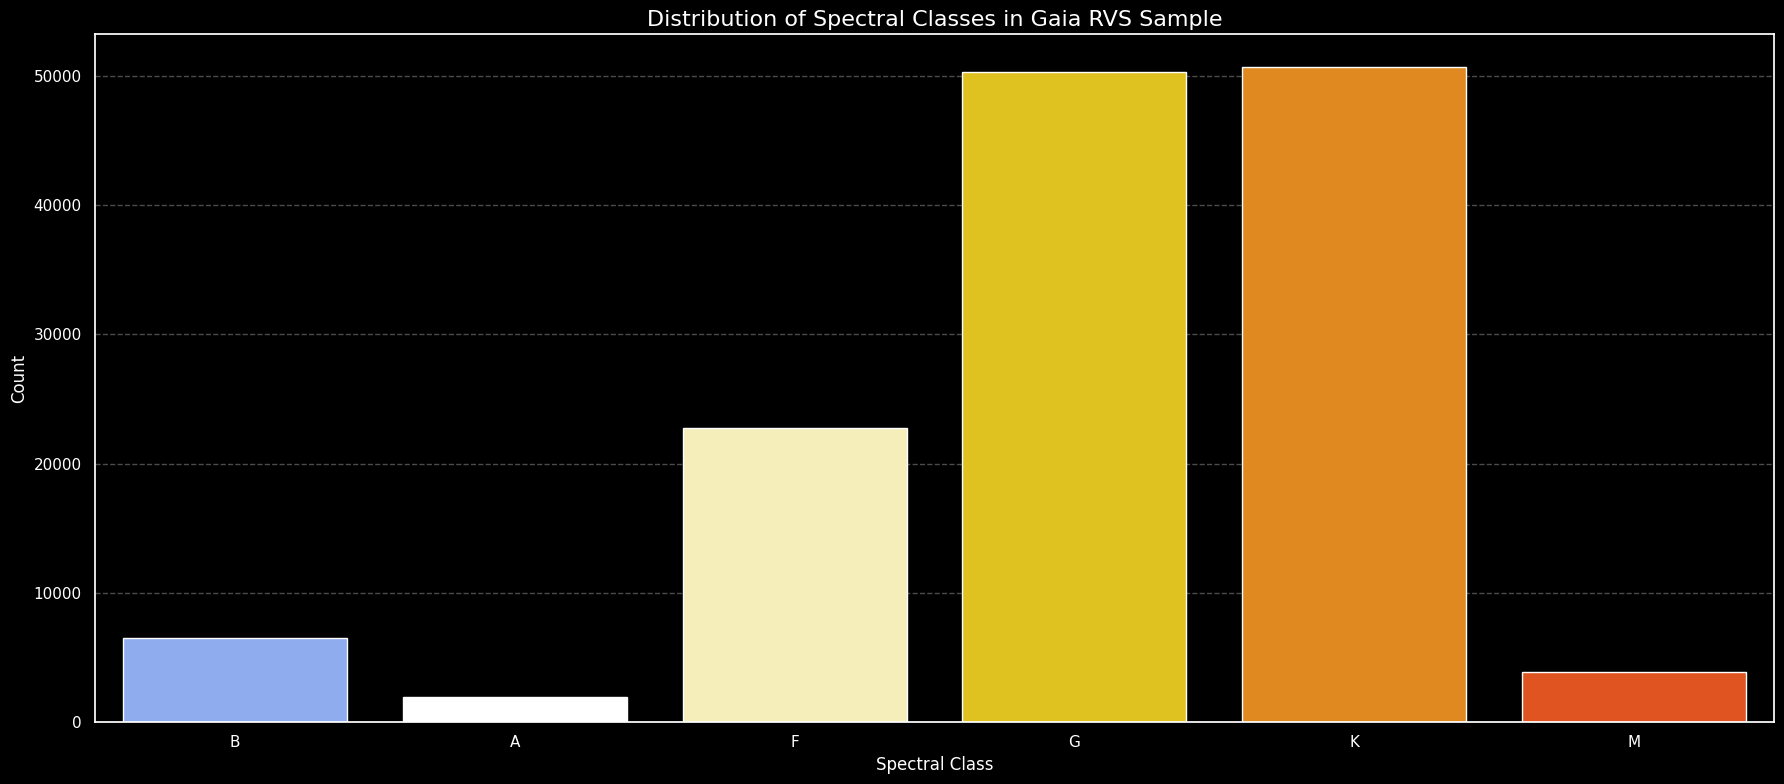

In [30]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Astronomical color palette
palette = {
    "B": "#7FA6FF",
    "A": "#FFFFFF",
    "F": "#FFF4B0",
    "G": "#FFD700",
    "K": "#FF8C00",
    "M": "#FF4500"
}

# "O": "#4B6CFF",

# Graph
plt.figure(figsize=(18,8))
ax = plt.gca()             # get current axes

sns.countplot(
    x="spectral_class",
    data=teff_clean,
    palette=palette,
    order=["B","A","F","G","K","M"] 
)

# Background
ax.set_facecolor("black")                # It changes the color into black in axs order
plt.gcf().patch.set_facecolor("black")   # Outside of figure

plt.title(
    "Distribution of Spectral Classes in Gaia RVS Sample",
    fontsize=16,
    color="white"
)

plt.xlabel("Spectral Class",color="white")
plt.ylabel("Count",color="white")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()

Imbalance Data

O Class => Hottest Stars, 🌡️ > 30,000 K, 🎨 Blue

B Class => 🌡️ 10,000 – 30,000 K, 🎨 Blue-White

A Class => 🌡️ 7,500 – 10,000 K, 🎨 White

F Class => 🌡️ 6,000 – 7,500 K, 🎨 Yellow-White

G Class => 🌡️ 5,200 – 6,000 K, 🎨 Yellow (Sun Here)

K Class => 🌡️ 3,700 – 5,200 K, 🎨 Orange

M Class => Coldest Stars, 🌡️ < 3,700 K, 🎨 Red

# Observation Quality

In [34]:
# combined_transits: The number of distinct times Gaia observed a star as it scanned the sky. 
#                   - Higher transit counts correlate with higher data reliability and lower uncertainty.

# combined_ccds: The total number of CCD (Charge-Coupled Device) observations across all transits. 
#                - These sensors convert light into data to measure position, brightness, and spectra. 
#                - More CCD observations result in more data points and a better signal-to-noise ratio.

# deblended_ccds: The frequency at which overlapping signals from multiple sources were detected and separated. 
#                 - Represents potentially problematic or complex measurements where flux was "deblended."
#                 - A lower count indicates a cleaner, single-source measurement and higher precision.

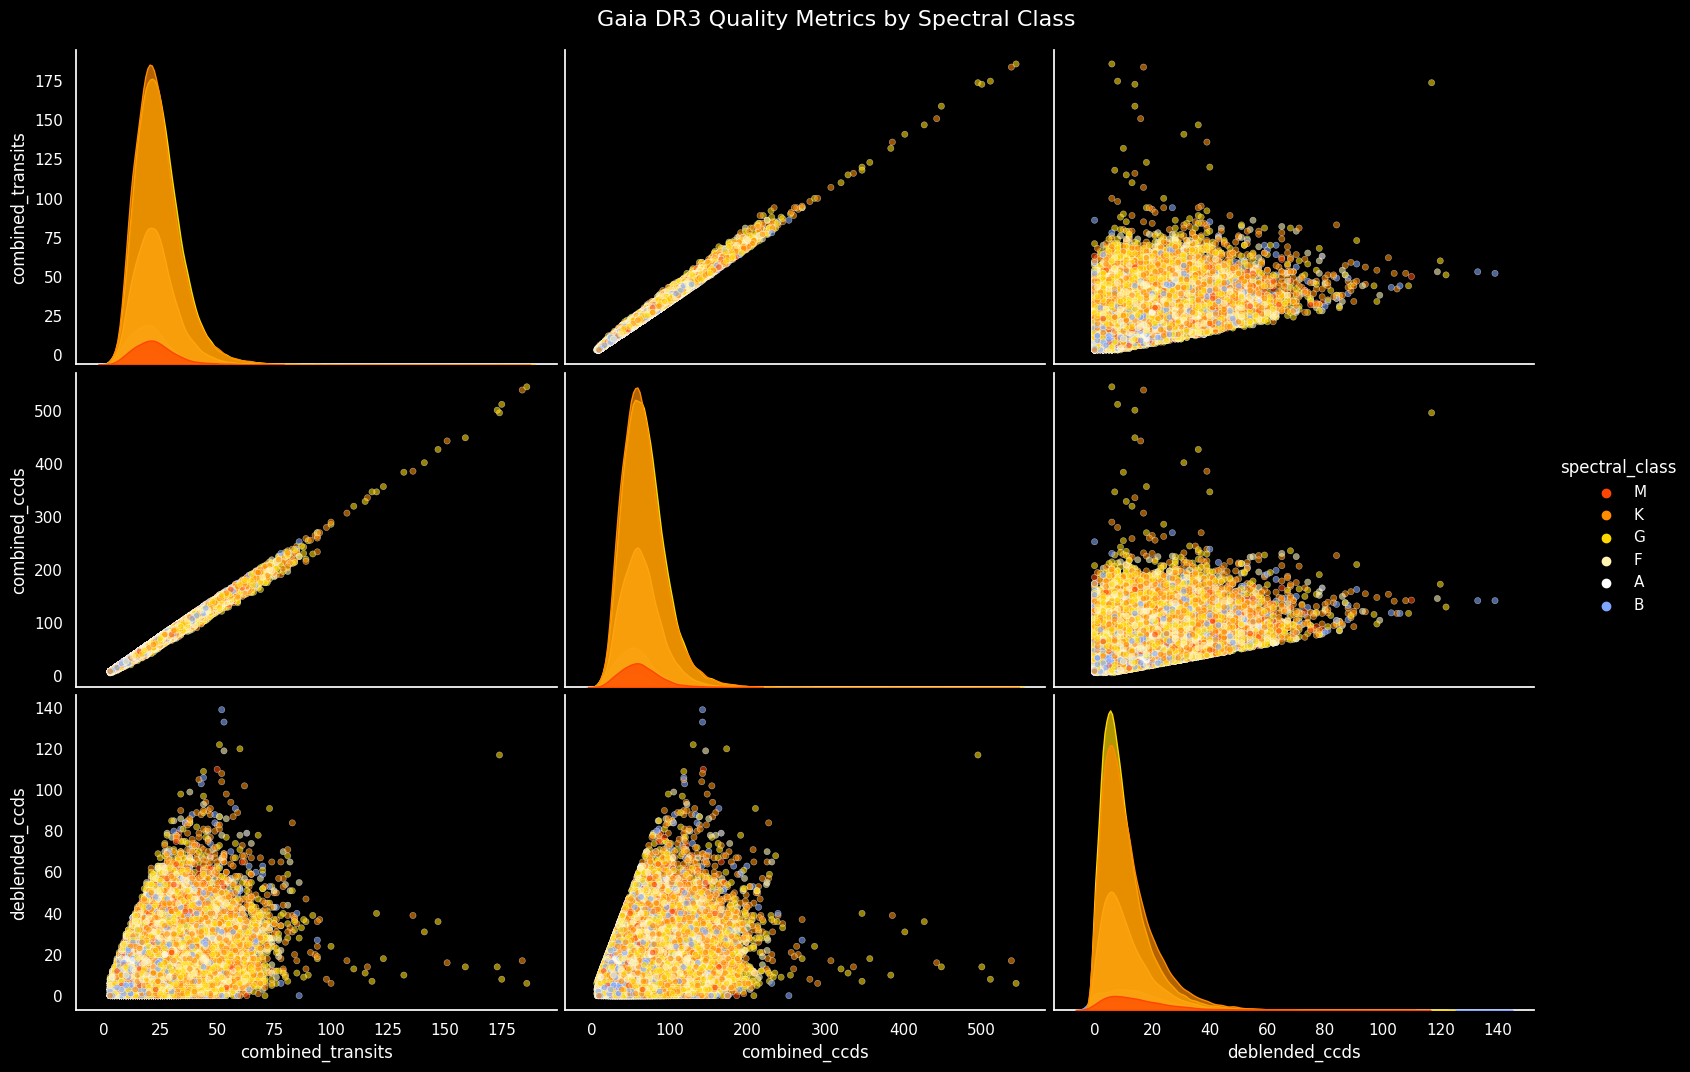

In [35]:
import warnings
warnings.filterwarnings("ignore")

g = sns.pairplot(
    teff_clean[["combined_transits","combined_ccds","deblended_ccds","spectral_class"]],
    hue="spectral_class",
    palette=palette,
    height=3.5,
    aspect=1.5,
    plot_kws={"alpha": 0.6, "s": 20},
    diag_kws={"alpha": 0.7}
)

g.fig.patch.set_facecolor("black")   # Outside color

for ax in g.axes.flatten():   # flatten converts the dimension into 1
    if ax is not None:
        ax.set_facecolor("black")

        ax.set_xlabel(ax.get_xlabel(), color="white")
        ax.set_ylabel(ax.get_ylabel(), color="white")

g.fig.suptitle(
    "Gaia DR3 Quality Metrics by Spectral Class",
    y=1.02,
    fontsize=16,
    color="white"
)

plt.show()

* In Scatter Plots, there is a perfect linear correlation between combined_transits and combined_ccds, these two features provide redundant information. In Gaia's scanning law, each transit corresponds to a fixed number of CCD observations. To prevent overfitting and reduce dimensionality, only one of these features should be retained for the classification model.
* In KDE Plots,(KDE) plots on the diagonal reveal a significant dominance of certain spectral classes. Classes like K (orange) and G (green) show high density, while early-type stars like O (pink) and B (brown) are underrepresented. ==> Class Imbalance
* The deblended_ccds distribution shows that most observations are clustered at lower values, regardless of the spectral type. Deblending occurs when Gaia resolves sources in crowded fields. Stars with low deblended counts relative to their total transits might have lower signal-to-noise ratios (SNR) in their spectra.

In [36]:
print("Minimum combined transits number: ",teff_clean["combined_transits"].min())
print("Maximum combined_transits number: ",teff_clean["combined_transits"].max())
print("Average combined transits number: ",teff_clean["combined_transits"].mean())

Minimum combined transits number:  3
Maximum combined_transits number:  186
Average combined transits number:  23.712753286474722


In [38]:
teff_clean[teff_clean["combined_transits"] > 150] # The maximum combined_transits star

,source_id,solution_id,ra,dec,combined_transits,combined_ccds,deblended_ccds,flux_norm,flux_error_norm,teff_gspphot,spectral_class
33788,1633289171189725184,5950420259779346465,268.504322,66.323702,174,496,117,"[0.9625109, 0.9625109, 0.9625109, 0.85508555, ...","[0.015862396, 0.015862396, 0.015862396, 0.0251...",5932.375488,G
33789,1633291851249300608,5950420259779346465,268.326447,66.308490,175,512,8,"[0.9766825, 0.9766825, 0.9766825, 0.9766825, 0...","[0.030963488, 0.030963488, 0.030963488, 0.0309...",5774.566895,G
33790,1633293156919362432,5950420259779346465,268.411162,66.392902,186,545,6,"[0.98433423, 0.98433423, 0.98433423, 0.9843342...","[0.048131775, 0.048131775, 0.048131775, 0.0481...",5914.250488,G
33794,1633298757556966912,5950420259779346465,268.807377,66.238262,159,449,14,"[0.9811417, 0.9811417, 0.9811417, 0.9811417, 1...","[0.03262502, 0.03262502, 0.03262502, 0.0326250...",5245.856934,G
33796,1633299857068397824,5950420259779346465,268.807722,66.284814,184,539,17,"[0.9768235, 0.9768235, 0.9768235, 0.9768235, 0...","[0.040977426, 0.040977426, 0.040977426, 0.0409...",4711.975098,K
33798,1633319098521888128,5950420259779346465,268.971654,66.510429,173,501,14,"[0.9992458, 0.9936282, 1.0055937, 1.0232328, 1...","[0.033433545, 0.03259196, 0.03286002, 0.033347...",5202.958984,G
33822,1633540169076682112,5950420259779346465,267.314086,66.486598,151,443,16,"[0.9778991, 0.9778991, 0.9778991, 0.9778991, 0...","[0.033743422, 0.033743422, 0.033743422, 0.0337...",5027.572266,K


In [39]:
print(f"Number of stars with less than 5 combined transits: {len(teff_clean[teff_clean['combined_transits'] < 5])}")
print(f"Number of stars with less than 15 combined CCDs: {len(teff_clean[teff_clean['combined_ccds'] < 15])}")
print(f"Number of stars with exactly 1 deblended CCD: {len(teff_clean[teff_clean['deblended_ccds'] == 1])}")

Number of stars with less than 5 combined transits: 340
Number of stars with less than 15 combined CCDs: 630
Number of stars with exactly 1 deblended CCD: 3704


In [40]:
mask_count = (teff_clean["combined_transits"] >= 5) & (teff_clean["combined_ccds"] >= 15)
mask_count.value_counts()

True     135382
False       630
Name: count, dtype: int64

In [41]:
df = teff_clean[mask_count]

print("Original data count: ",len(teff_clean))
print("Cleaned data count: ", len(df))

Original data count:  136012
Cleaned data count:  135382


In [42]:
df.iloc[1]

source_id                                          4313633533114147456
solution_id                                        5950420259779346465
ra                                                           284.87979
dec                                                           11.87719
combined_transits                                                   11
combined_ccds                                                       28
deblended_ccds                                                      13
flux_norm            [0.934563, 0.9105238, 0.87870216, 0.88756484, ...
flux_error_norm      [0.04333024, 0.046265773, 0.044620022, 0.04408...
teff_gspphot                                              10175.013672
spectral_class                                                       B
Name: 3, dtype: object

In [43]:
df["ra"].iloc[1]

284.8797903101343

# Create the Model

In [44]:
df.head()

,source_id,solution_id,ra,dec,combined_transits,combined_ccds,deblended_ccds,flux_norm,flux_error_norm,teff_gspphot,spectral_class
0,5950415474817898496,5950420259779346465,259.350995,-49.004257,21,59,12,"[0.9151915, 0.9151915, 0.9151915, 0.9151915, 0...","[0.045158558, 0.045158558, 0.045158558, 0.0451...",4722.206543,K
3,4313633533114147456,5950420259779346465,284.879790,11.877190,11,28,13,"[0.934563, 0.9105238, 0.87870216, 0.88756484, ...","[0.04333024, 0.046265773, 0.044620022, 0.04408...",10175.013672,B
4,4313635495946970880,5950420259779346465,284.741712,11.863494,9,27,14,"[0.91765034, 0.911953, 0.94897735, 1.0375087, ...","[0.041686416, 0.042669877, 0.040802132, 0.0427...",4652.980957,K
5,4313637454452088064,5950420259779346465,284.786058,11.929722,14,38,11,"[0.95879865, 0.969211, 0.98452026, 0.93803483,...","[0.07722866, 0.05449455, 0.04903083, 0.0572972...",4528.703613,K
8,4313641680700807040,5950420259779346465,285.187661,11.819357,8,20,8,"[0.90507793, 0.90628743, 0.9240893, 0.94930977...","[0.011879738, 0.019234193, 0.022490185, 0.0281...",3590.169678,M


In [45]:
df["flux_norm"].values # We already store this column as a NumPy array, so if we use `.values`, it becomes a structure with an array within an array.

array([array([0.9151915 , 0.9151915 , 0.9151915 , ..., 1.0406576 , 0.99664366,
              0.9259493 ], dtype=float32)                                     ,
       array([0.934563  , 0.9105238 , 0.87870216, ..., 0.9810175 , 0.9972425 ,
              1.0063785 ], dtype=float32)                                     ,
       array([0.91765034, 0.911953  , 0.94897735, ..., 0.9305017 , 0.9305017 ,
              0.9305017 ], dtype=float32)                                     ,
       ...,
       array([0.9715113, 0.8104858, 0.8492252, ..., 1.0215466, 0.9110779,
              0.9034489], dtype=float32)                                 ,
       array([0.9812157 , 0.9812157 , 0.9812157 , ..., 0.91595423, 0.8944025 ,
              0.9322746 ], dtype=float32)                                     ,
       array([0.86151135, 0.89861286, 0.93739736, ..., 1.029541  , 1.0387517 ,
              1.0450176 ], dtype=float32)                                     ],
      dtype=object)

In [46]:
np.stack(df["flux_norm"].values)  # Previously, each row held a numpy array; when we use stack, we add dimensions, so it becomes a single large 2D Numpy array, (14044,2401)

array([[0.9151915 , 0.9151915 , 0.9151915 , ..., 1.0406576 , 0.99664366,
        0.9259493 ],
       [0.934563  , 0.9105238 , 0.87870216, ..., 0.9810175 , 0.9972425 ,
        1.0063785 ],
       [0.91765034, 0.911953  , 0.94897735, ..., 0.9305017 , 0.9305017 ,
        0.9305017 ],
       ...,
       [0.9715113 , 0.8104858 , 0.8492252 , ..., 1.0215466 , 0.9110779 ,
        0.9034489 ],
       [0.9812157 , 0.9812157 , 0.9812157 , ..., 0.91595423, 0.8944025 ,
        0.9322746 ],
       [0.86151135, 0.89861286, 0.93739736, ..., 1.029541  , 1.0387517 ,
        1.0450176 ]], dtype=float32)

In [47]:
X = np.stack(df["flux_norm"].values)   # np.stack takes multiple numpy arrays and combines them into a single array by adding a new dimension
y = df["spectral_class"].values                  

In [48]:
print("Shape of the input: ",X.shape)
print("Shape of the output: ",y.shape)

Shape of the input:  (135382, 2401)
Shape of the output:  (135382,)


In [49]:
from sklearn.model_selection import train_test_split # split the data into train and test
from sklearn.preprocessing import LabelEncoder       # It's converting categorical data into numerical by assigning a unique integer to each category
from sklearn.preprocessing import MinMaxScaler       # Standardizes features by scaling each feature to a given range

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)

In [50]:
print("Shape of X_train: ",X_train.shape)
print("Shape of X_test: ",X_test.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_test: ",y_test.shape)

Shape of X_train:  (108305, 2401)
Shape of X_test:  (27077, 2401)
Shape of y_train:  (108305,)
Shape of y_test:  (27077,)


In [51]:
# label encoding is directly converts categorical data into integers such as 0,1,2,3
# one hot encoder, creates a new column for each class and returns 1, if it belongs to that class, otherwise 0,Class F -> [1, 0, 0, 0], Class G -> [0, 1, 0, 0].
# ordinal encoding is used if there is a hierarchical order between classes such as low,medium,high => 1,2,3

In [52]:
le = LabelEncoder()
y_train = le.fit_transform(y_train) # fit parts learns the classes and assign numbers to every class and transform the string data
y_test = le.transform(y_test)       # we are apply just transform in test set othrwise it may leads to data leakage

In [53]:
# Standard Scaler, scale the data so that the mean is 0 and the sandard deviation is 1. (strong for outliers)
# MinMaxScaler, scale the data between 0 and 1. (sensitive for outliers)

X.mean()

0.9550559

In [54]:
scaler = MinMaxScaler()                  # squeeze the data between 0 and 1
X_train = scaler.fit_transform(X_train)  # fits learns the data, transform, transform this data that it learned from fits
X_test = scaler.transform(X_test)        # we do not want fit because it causes to data leakage, so just apply the transformation

NOTE:

rngs = random number generator state — the source of randomness used by NNX.
If a layer requires randomness, it needs the rngs parameter.

Conv, Linear:

Use random values when initializing weights.

Dropout:

Randomly deactivates some neurons during training → requires a specific RNG.

BatchNorm:

Calculates mean/variance for normalization. RNG can be used to control training vs. inference behavior.

Conv + Pool output size:
in_features = channels × height × width

(For 1D spectra: channels × length)

In [55]:
import numpy as np

x = np.array([[1, 2, 3],
              [4, 5, 6]])
x.shape

print("before y: ",x)

y = x.reshape(-1)
print("after y: ",y)

before y:  [[1 2 3]
 [4 5 6]]
after y:  [1 2 3 4 5 6]


Ex:

Conv1 (3×3, 32 filters) → learns edges and corners, extracts basic features.

Conv2 (3×3, 64 filters) → learns more complex patterns.

Pooling → reduces the spatial size and condenses information.

Flatten → flattens the feature maps into a single vector.

Linear layers (Dense layers) → make the final decision about which class the input belongs to; produce logits for classification.

In [56]:
from flax import nnx          # nnx is the API of flax, (Object Oriented API)
from functools import partial # partial is used for prefixing some arguments to a function

class CNN(nnx.Module):        # with nnx.module,CNN can act like a neural network model

    def __init__(self, *, rngs:nnx.Rngs):                         # rngs = random number generator, to define the initial values of weights in the layers
        self.conv1 = nnx.Conv(1,16, kernel_size=(7,), rngs=rngs)  # (in_channels,out_channels), 
        self.batch_norm1 = nnx.BatchNorm(16,rngs=rngs)            # It normalizing the activations coming out of convolution layers, 16 özellik haritası kanalındaki verilerin hepsini aynı ölçeğe getirir
        self.dropout1 = nnx.Dropout(rate=0.2, rngs=rngs)

        self.conv2 = nnx.Conv(16,32, kernel_size=(5,), rngs=rngs) # our data is 1D ==> (3,)
        self.batch_norm2 = nnx.BatchNorm(32, rngs=rngs)
        self.dropout2 = nnx.Dropout(rate=0.2, rngs=rngs)

        self.conv3 = nnx.Conv(32,64, kernel_size=(3,), rngs=rngs)
        self.batch_norm3 = nnx.BatchNorm(64, rngs=rngs)

        self.avg_pool = partial(nnx.avg_pool, window_shape=(2,), strides=(2,)) # window_shape and stride parameters are fixed by nnx.partial

        # nnx.Linear(in_features, out_features), 
        # in => The size of the vector that will enter the linear layer
        # out => The size of the hidden layer(that I choose)
        
        self.linear1 = nnx.Linear(19200,256, rngs=rngs) # 64 x 300 = 19200 (before entering the CNN layer, the model size is (bs,64,300))
        self.dropout3 = nnx.Dropout(rate=0.2, rngs=rngs)
        self.linear2 = nnx.Linear(256,6, rngs=rngs)     # 256 is the exit size of the linear1, 6 is for spectral classes(logits)

    def __call__(self,x):
        x = self.avg_pool(self.dropout1(nnx.relu(self.batch_norm1(self.conv1(x)))))
        x = self.avg_pool(self.dropout2(nnx.relu(self.batch_norm2(self.conv2(x)))))
        x = self.avg_pool(nnx.relu(self.batch_norm3(self.conv3(x))))
        x = x.reshape(x.shape[0], -1)  # Flatting process, save the x.shape[0] which is batch size, and combine all remaining dimensions into a single vector
        x = nnx.relu(self.dropout3(self.linear1(x)))
        x = self.linear2(x)            # Final output, scores(logits) are produced for 6 classes
        return x

model = CNN(rngs=nnx.Rngs(0))
nnx.display(model)

# activation function provides a complexity to the model  ==> Tensor Shape: (Batch Size, Channel, Length)
# (bs,1,2401) => (bs,16,2401) => (bs,16,1200) => (bs,32,1200) => (bs,32,600) ==> (bs,64,600) ==> (bs,64,300) ==> channels x length = 19200, the result is (bs,19200) 

INFO:2026-04-07 11:58:02,103:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-04-07 11:58:02,126:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [ ]:
# Test the model
import jax.numpy as jnp
model = CNN(rngs=nnx.Rngs(0)) 
x = jnp.ones((8, 2401,1))       # normally (batchsize, channels, length), but flax accepts channel last so change their location
y = model(x)

print("Output size:", y.shape)   # (8, 6) → 6 for spectral classes
nnx.display(model)              

In [58]:
import optax # It is an optimizer library for JAX

learning_rate = 0.005 # How much the weights will be updated at each step
momentum = 0.9        # makes updates more stable

optimizer = nnx.Optimizer(model, optax.adamw(learning_rate,momentum), wrt=nnx.Param) # nnx.Param means, this value is the parameter to be learned
metrics = nnx.MultiMetric(accuracy=nnx.metrics.Accuracy(), loss = nnx.metrics.Average("loss"),) # Monitor accuracy and average loss simultaneously in every bach

nnx.display(optimizer)

In [ ]:
# Normally, in libraries with high APIs, you would just say batch_size=32 or something like that, but you need to define it yourself first. ==> Low API

Forward pass: The stage where data is passed through the model to compute the output (logits) and loss — the model makes predictions and the error is measured.

Backward pass: The stage where the model calculates how its weights should change based on the computed error (gradient calculation), i.e., derivatives are taken.

In [59]:
import jax.numpy as jnp

weights_array = jnp.array([5.5, 3.0, 0.9, 0.5, 0.4, 3.5])  # Class Weight for imbalance data, ["A","B"","F"","G","K","M"]

# Forward pass
def loss_fn(model: CNN, batch):   # It means that a CNN type object is expected
    logits = model(batch["flux"]) # Logits are scores that produced by the model for each class
    labels = batch["label"]
    
    sample_weights = weights_array[labels] # Select the weight of each data point in the batch according to its own class, such as [0.4, 0.4, 7.0, 0.4]
    
    # Calculate the unweighted loss values.  As a Loss function used Softmax Cross-Entropy Loss. If the model gives a low probability of being the correct class, it punish very severely. (log function)
    per_example_loss = optax.softmax_cross_entropy_with_integer_labels(logits=logits, labels=labels) # logits are converted to possibilities with softmax function. It's compared with the real label 
    
    weighted_loss = jnp.mean(per_example_loss * sample_weights)
    return weighted_loss, logits  # return loss, logits, loss shows how wrong the model is with a numerical value, logits for calculating the metrics.

# Backward pass
@nnx.jit
def train_step(model: CNN, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, batch): # Train the model for a single batch/step
    # nnx.value_and_grad creates a new function that calculates both the output and the gradient of a function in a single step.
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)  # grads, gives a list of how much the weights need to be updated, has_aux indicates besides the loss, there will be extra things return as well.
    (loss, logits), grads = grad_fn(model, batch)      
    metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates
    optimizer.update(grads)  # In-place updates

@nnx.jit
def eval_step(model: CNN, metrics: nnx.MultiMetric, batch):
    loss, logits = loss_fn(model,batch) # just forward passing
    metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.

In [60]:
# jax.jit => Tracing, JAXPR, XLA, Cache

In [61]:
num_epochs = 50   # Epoch is one full pass of the entire training dataset through the neural network
batch_size = 128  # Batch Size is the number of training examples

train_epoch_loss = []
train_epoch_accuracy = []

for epoch in range(num_epochs):
    metrics.reset()   # Reset the metrics to take new measurements at each epoch

    for i in range(0, len(X_train), batch_size): # start from 0, finish from len, and skip by batch_size

        X_batch = X_train[i:i+batch_size]       
        Y_batch = y_train[i:i+batch_size]

        X_batch = X_batch.reshape(X_batch.shape[0], X_batch.shape[1], 1)   # Reshape for adapting it to suit CNN. (batch,length,channel),1 means add an new axis

        batch = {"flux":X_batch, "label":Y_batch}    # batch is a data that gave to the model during training
        train_step(model,optimizer,metrics,batch)

    epoch_loss = metrics.loss.compute()
    train_epoch_loss.append(epoch_loss)
    
    epoch_acc = metrics.accuracy.compute()
    train_epoch_accuracy.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

# X_train shape: (108305,2401)
# First X_batch: (128,2401)
# After reshape: (128,2401,1)

Epoch 1/50 | Loss: 0.9302 | Accuracy: 0.7473
Epoch 2/50 | Loss: 0.4360 | Accuracy: 0.7942
Epoch 3/50 | Loss: 0.4122 | Accuracy: 0.8055
Epoch 4/50 | Loss: 0.3877 | Accuracy: 0.8185
Epoch 5/50 | Loss: 0.3748 | Accuracy: 0.8237
Epoch 6/50 | Loss: 0.3652 | Accuracy: 0.8275
Epoch 7/50 | Loss: 0.3537 | Accuracy: 0.8310
Epoch 8/50 | Loss: 0.3469 | Accuracy: 0.8324
Epoch 9/50 | Loss: 0.3380 | Accuracy: 0.8360
Epoch 10/50 | Loss: 0.3324 | Accuracy: 0.8368
Epoch 11/50 | Loss: 0.3214 | Accuracy: 0.8393
Epoch 12/50 | Loss: 0.3144 | Accuracy: 0.8431
Epoch 13/50 | Loss: 0.3069 | Accuracy: 0.8452
Epoch 14/50 | Loss: 0.3007 | Accuracy: 0.8461
Epoch 15/50 | Loss: 0.2964 | Accuracy: 0.8487
Epoch 16/50 | Loss: 0.2915 | Accuracy: 0.8495
Epoch 17/50 | Loss: 0.2877 | Accuracy: 0.8512
Epoch 18/50 | Loss: 0.2837 | Accuracy: 0.8525
Epoch 19/50 | Loss: 0.2735 | Accuracy: 0.8569
Epoch 20/50 | Loss: 0.2733 | Accuracy: 0.8563
Epoch 21/50 | Loss: 0.2700 | Accuracy: 0.8581
Epoch 22/50 | Loss: 0.2683 | Accuracy: 0.85

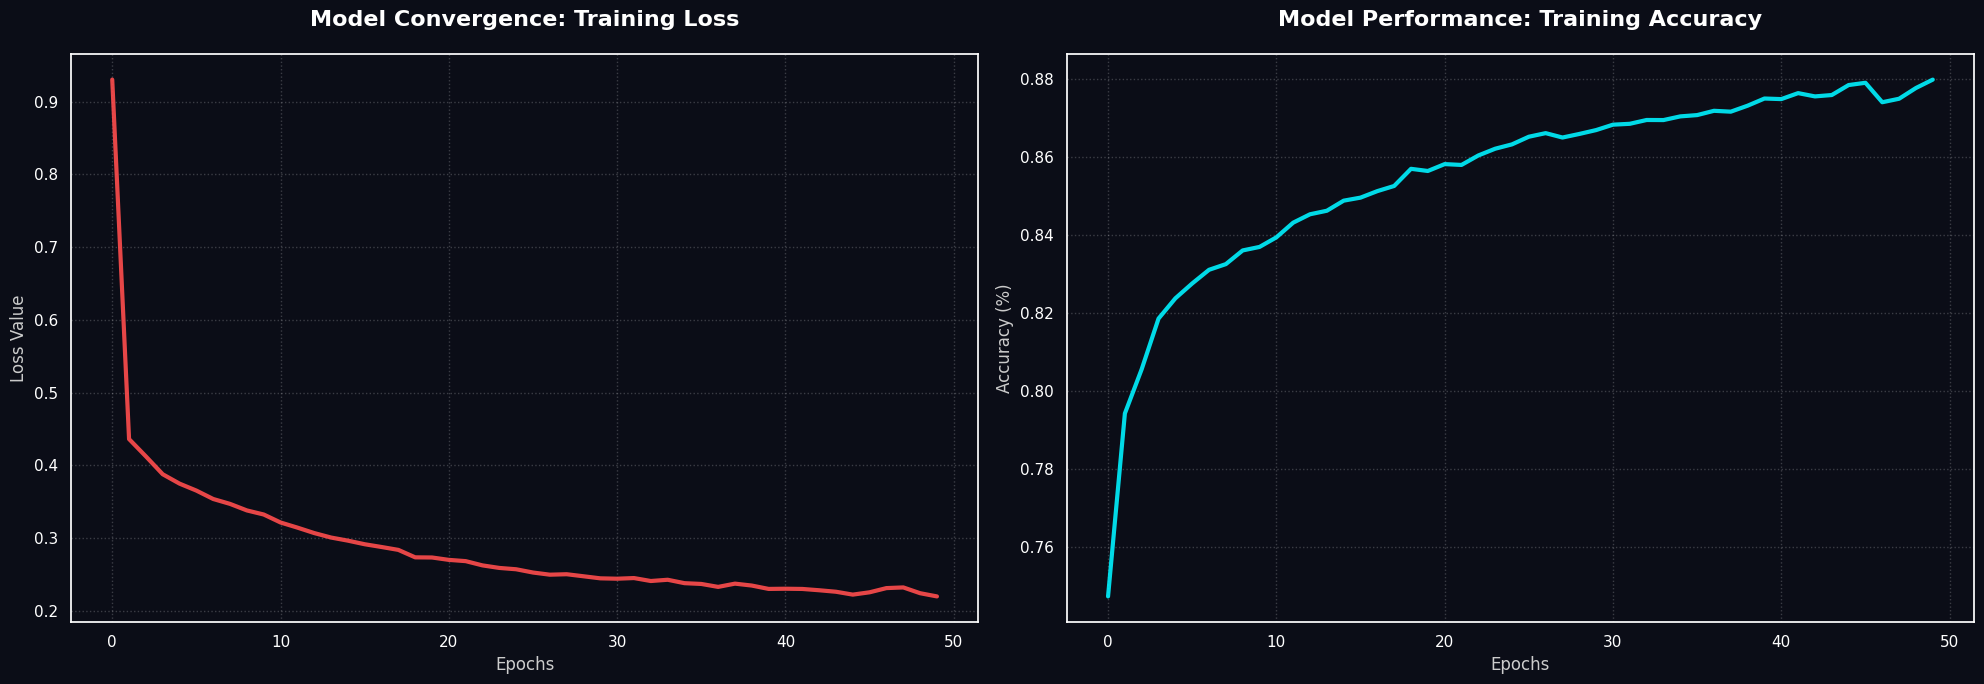

In [62]:
# Dark Background
plt.style.use('dark_background') 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
fig.patch.set_facecolor('#0b0d17')

# --- Loss Graph ---
axes[0].set_facecolor('#0b0d17')
axes[0].plot(train_epoch_loss, label='Training Loss', color='#ff4d4d', lw=3, alpha=0.9) 
axes[0].set_title("Model Convergence: Training Loss", fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel("Epochs", color='#cccccc')
axes[0].set_ylabel("Loss Value", color='#cccccc')
axes[0].grid(True, linestyle=':', alpha=0.2)

# --- Accuracy Graph ---
axes[1].set_facecolor('#0b0d17')
axes[1].plot(train_epoch_accuracy, label='Training Accuracy', color='#00f2ff', lw=3, alpha=0.9)
axes[1].set_title("Model Performance: Training Accuracy", fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel("Epochs", color='#cccccc')
axes[1].set_ylabel("Accuracy (%)", color='#cccccc')
axes[1].grid(True, linestyle=':', alpha=0.2)

plt.tight_layout()
plt.show()

In [63]:
all_test_preds = []   # The list stores all predictions(such as A,B,F,G..) for each star in the test set
all_test_labels = []  # The list stores actual class of stars(the correct asnwer key)

metrics.reset()
test_batch_size = 128

for i in range(0, len(X_test), test_batch_size):    # Start from 0 to length of the test size, skip 32 in ever step
    X_test_batch = X_test[i:i+test_batch_size]      # (128,2401)
    Y_test_batch = y_test[i:i+test_batch_size]
    
    X_test_batch = X_test_batch.reshape(-1, X_test_batch.shape[1], 1)  # The data is being scaled to the size required by model (1D CNN)  (batchsize, feature_length, channel)
    
    # Get the logits from model
    logits = model(X_test_batch)  # Such as First Flux Data Logits: [8.9, -0.5, 1.2, 0.3, -1.1, 0.2, -0.7], preds takes the 8.9 index number
    
    # Choose the class with the highest logit score (0, 1, 2... whichever it is)
    preds = np.argmax(logits, axis=1)
    
    # Adding to the lists
    all_test_preds.extend(preds)
    all_test_labels.extend(Y_test_batch)

    batch = {"flux": X_test_batch, "label": Y_test_batch}
    eval_step(model, metrics, batch)

# Final Results
final_test_loss = metrics.loss.compute()
final_test_acc = metrics.accuracy.compute()

print(f"Test Loss: {final_test_loss:.4f} | Test Acc: {final_test_acc:.4f}")

# X_test shape: (27077,2401)
# First X_batch: (128,2401)
# After reshape: (128,2401,1)

Test Loss: 0.6600 | Test Acc: 0.8049


In [64]:
# Classification Report
from sklearn.metrics import classification_report

target_names = ['A', 'B', 'F', 'G', 'K', 'M'] 
unique_labels = np.unique(all_test_labels)
current_target_names = [target_names[i] for i in unique_labels]

print("\n Classification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=current_target_names))


 Classification Report:
              precision    recall  f1-score   support

           A       0.47      0.34      0.39       342
           B       0.80      0.95      0.87      1253
           F       0.75      0.68      0.72      4413
           G       0.75      0.82      0.79     10195
           K       0.90      0.84      0.87     10100
           M       0.89      0.96      0.92       774

    accuracy                           0.81     27077
   macro avg       0.76      0.76      0.76     27077
weighted avg       0.81      0.81      0.81     27077



In [ ]:
!pip install scikit-learn==1.5.2 umap-learn==0.5.6

In [65]:
import jax.numpy as jnp

# Settings
model.train = False
batch_size = 64
all_logits_list = []

X_test_reshaped = X_test.reshape(-1, X_test.shape[1], 1)  # Save the X_test.shape[0] and X_test.shape[1] and add an extra channel

print(f"Total samples: {len(X_test_reshaped)}. Processing in batches...")

# Get predictions with using loop
for i in range(0, len(X_test_reshaped), batch_size):
    batch = X_test_reshaped[i:i+batch_size]
    
    logits = model(batch) 
    all_logits_list.append(logits)  # Collect all logits in the batch sizes, do not convert anything because UMAP tries to find similarities between data

# 3. Concatenate all results into a single array
all_logits = jnp.concatenate(all_logits_list, axis=0)

Total samples: 27077. Processing in batches...
Prediction complete! Now you can run UMAP.


Calculating UMAP projection for 26k samples... This might take 1-2 minutes.


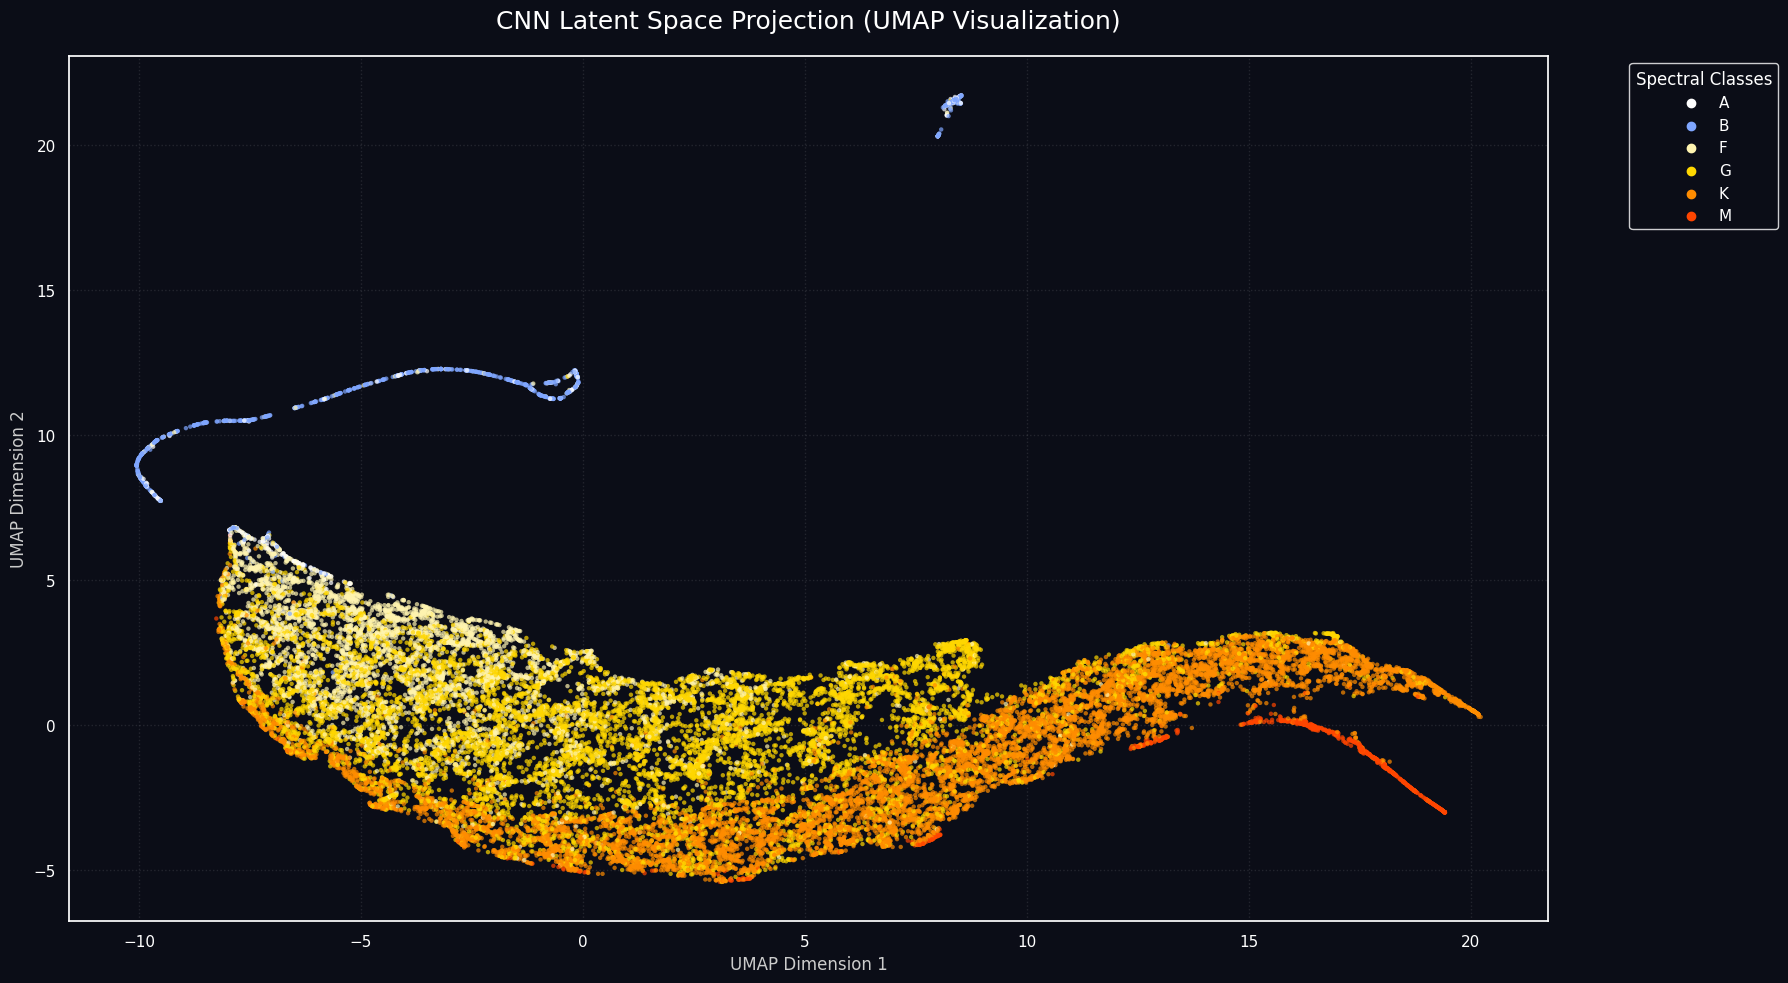

In [86]:
from umap import UMAP

# 1. UMAP Configuration
reducer = UMAP(n_neighbors=30, min_dist=0.01, metric='euclidean', random_state=42)  # n_neighbours indicates number of neighbors data when calculating the similartiy score
                                                                                    # euclidean uses standard straight-line distance to measure the similarity between two stars
print("Calculating UMAP projection for 26k samples... This might take 1-2 minutes.")
embedding_2d = reducer.fit_transform(np.array(all_logits)) # Learns the distances and similarities of 26843 stars, and reduce the shape onto 2 dimensional

# 2. Visualization
plt.figure(figsize=(18, 10))
fig = plt.gcf()
fig.patch.set_facecolor('#0b0d17') # Dark background to match your theme
ax = plt.gca()
ax.set_facecolor('#0b0d17')

target_names = ['A', 'B', 'F', 'G', 'K', 'M']  # Use predefined astronomical palette

labels_for_plot = [target_names[int(i)] for i in all_test_labels] # all_test_labels => y_test data

scatter = sns.scatterplot(
    x=embedding_2d[:, 1],   # Choose the all rows and take the first column
    y=embedding_2d[:, 0],   # Choose the all rows and take the second column
    hue=labels_for_plot,
    hue_order=target_names,
    palette=palette,
    s=10,
    alpha=0.7,
    edgecolor='none'
)

plt.title('CNN Latent Space Projection (UMAP Visualization)', fontsize=18, color='white', pad=20)
plt.xlabel('UMAP Dimension 1', color='#cccccc')
plt.ylabel('UMAP Dimension 2', color='#cccccc')

# Legend update
plt.legend(title='Spectral Classes', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='#0b0d17', edgecolor='white', labelcolor='white')

plt.grid(True, linestyle=':', alpha=0.1)
plt.tight_layout()
plt.show()